In [18]:
import os
import matplotlib.pyplot as plt
import numpy as np
from optiland.fileio import load_zemax_file
from optiland import analysis

In [19]:
# Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

In [20]:
# === 1. Zielordner definieren ===
output_dir = r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses"

# Ordner automatisch erstellen, falls er nicht existiert
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === 2. URLs der Thorlabs .zmx Dateien ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 3. Linsen laden ===
print("Loading lens models...")
lens_sphaere = load_zemax_file(url_sphaere)
lens_asphaere = load_zemax_file(url_asphaere)
lens_kolli = load_zemax_file(url_kolli)

# === 4. Funktion zum Generieren einzelner Plots ===
def save_lens_plot(lens_obj, title_text, filename, x_limit=None):
    plt.figure(figsize=(10, 4))
    try:
        lens_obj.draw()
        
        # Falls die Achsen durch das Assembly explodieren, manuell zoomen
        if x_limit:
            plt.xlim(x_limit)
            
    except Exception as e:
        print(f"Hinweis beim Zeichnen von {filename}: {e}")
        plt.text(0.5, 0.5, "Ray trace preview unavailable for this specific assembly structure\n(See Zemax Spot Diagrams for optical performance)", 
                 horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    
    plt.title(title_text, fontsize=12, fontweight="bold", loc="left")
    plt.xlabel("Z [mm]")
    plt.ylabel("Y [mm]")
    plt.tight_layout()
    
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath)
    plt.show()
    plt.close()
    print(f"Gespeichert unter: {filepath}")

# === 5. Einzeln ausführen und speichern ===
print("Generating spherical lens plot...")
save_lens_plot(lens_sphaere, "Spherical Lens (Thorlabs LA1422-C)", "Lens_Layout_Spherical.pdf")

print("Generating aspheric lens plot...")
save_lens_plot(lens_asphaere, "Aspheric Lens (Thorlabs AL5040H-B)", "Lens_Layout_Aspheric.pdf")

print("Generating collimator plot...")
save_lens_plot(lens_kolli, "Fiber Collimator (Thorlabs F810APC-1064)", "Lens_Layout_Collimator.pdf", x_limit=(-5, 50))




Loading lens models...
Generating spherical lens plot...
Gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Spherical.pdf
Generating aspheric lens plot...
Gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Aspheric.pdf
Generating collimator plot...
Gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Collimator.pdf


<Figure size 3000x1200 with 0 Axes>

<Figure size 3000x1200 with 0 Axes>

<Figure size 3000x1200 with 0 Axes>

In [21]:
# === 6. Kombinierten Plot mit allen 3 Linsen untereinander erstellen ===
print("Generating combined vertical comparison plot...")
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# (a) Sphärische Linse
try:
    lens_sphaere.draw(ax=axes[0])
except Exception as e:
    pass
axes[0].set_title("(a) Spherical Lens (Thorlabs LA1422-C)", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Y [mm]")

# (b) Asphärische Linse
try:
    lens_asphaere.draw(ax=axes[1])
except Exception as e:
    pass
axes[1].set_title("(b) Aspheric Lens (Thorlabs AL5040H-B)", fontsize=12, fontweight="bold", loc="left")
axes[1].set_ylabel("Y [mm]")

# (c) Kollimator (mit korrigiertem Zoom)
try:
    lens_kolli.draw(ax=axes[2])
    axes[2].set_xlim(-5, 50)
except Exception as e:
    axes[2].text(0.5, 0.5, "Ray trace preview unavailable", transform=axes[2].transAxes, ha='center', va='center')
axes[2].set_title("(c) Fiber Collimator (Thorlabs F810APC-1064)", fontsize=12, fontweight="bold", loc="left")
axes[2].set_ylabel("Y [mm]")
axes[2].set_xlabel("Z [mm]")

plt.tight_layout()
combined_filepath = os.path.join(output_dir, "Lens_Layout_Comparison_Combined.pdf")
plt.savefig(combined_filepath)
plt.show()
plt.close()
print(f"Kombinierter Plot gespeichert unter: {combined_filepath}")

Generating combined vertical comparison plot...
Kombinierter Plot gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Comparison_Combined.pdf


Simuliere Sphäre...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_19220/3538374295.py:15: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()


Simuliere Asphäre...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_19220/3538374295.py:15: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()


Simuliere Kollimator...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_19220/3538374295.py:15: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()


Plot gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/ToleranceAnalysis_Piezo_U_Curve.pdf


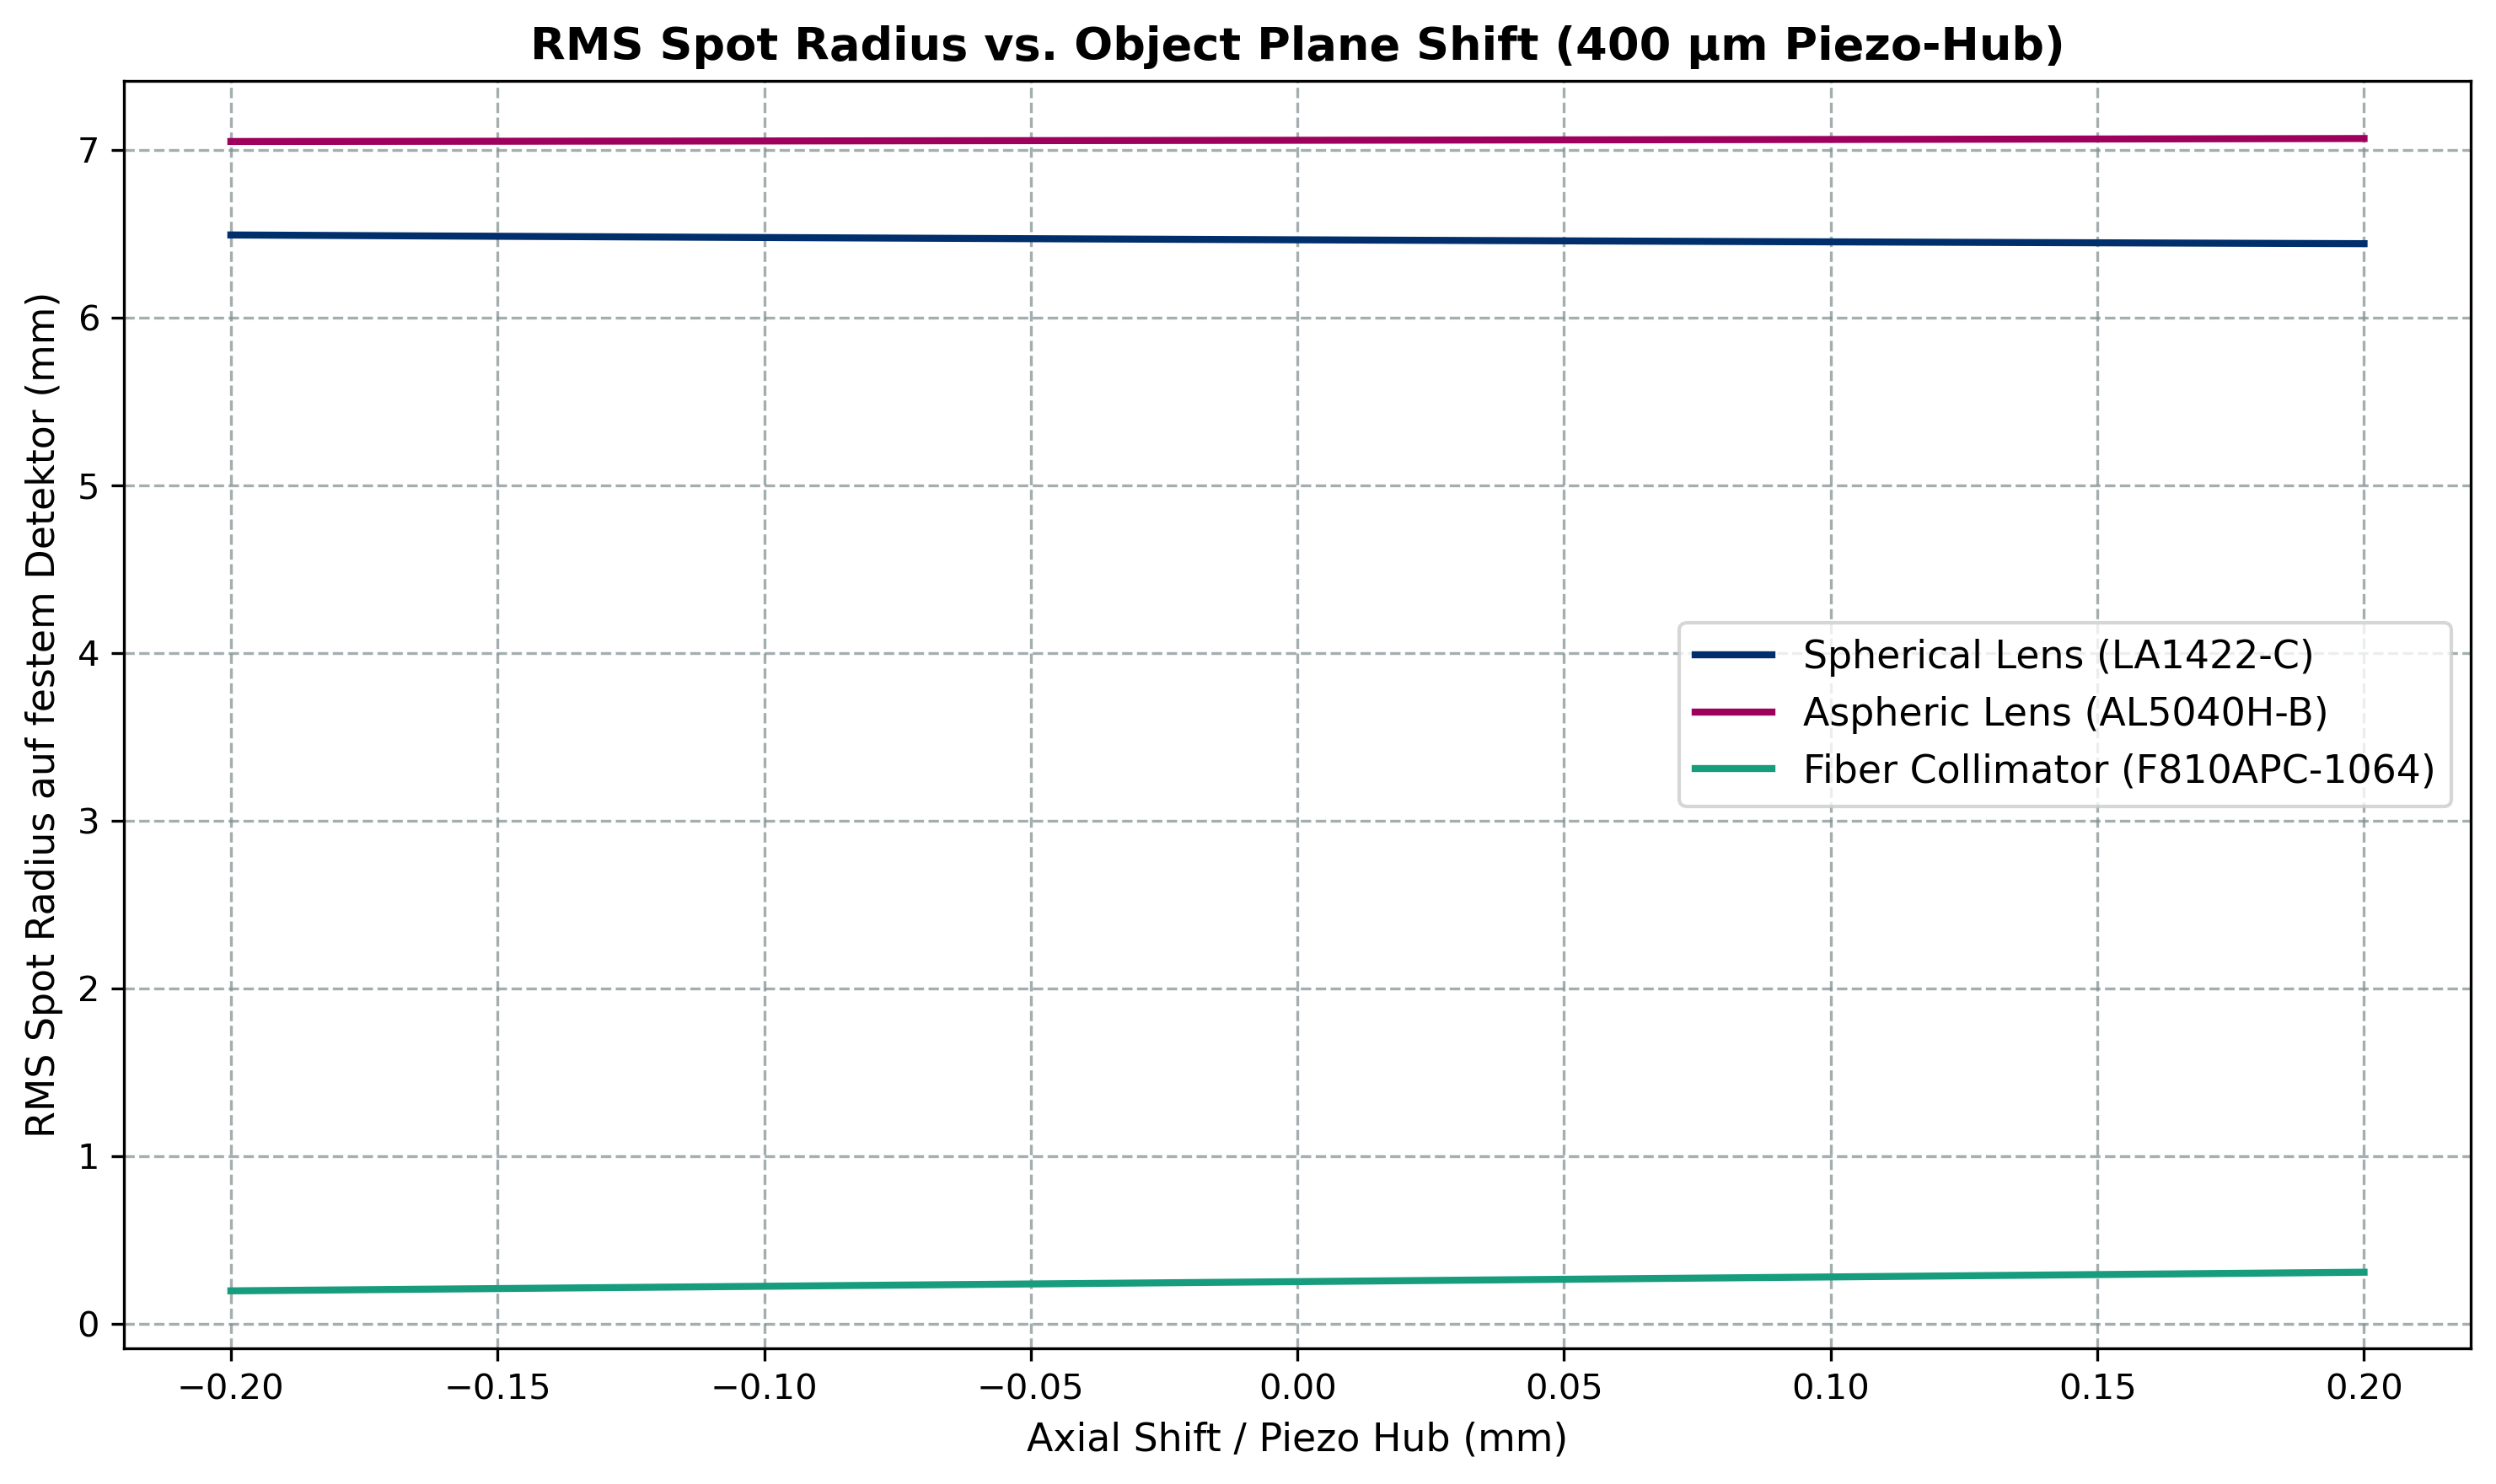

In [22]:


# === 1. Deine Thorlabs-Linsen ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 2. Dein Piezo-Hub (400 µm) ===
# Wir simulieren +/- 0.2 mm um die Nulllage
dz = np.linspace(-0.2, 0.2, 64)

def simuliere_echten_piezo(url, dz_array, start_distanz=15.0):
    lens = load_zemax_file(url)
    
    # A) Einmalig den perfekten Fokus finden (Sensor positionieren)
    lens.updater.set_thickness(value=start_distanz, surface_number=0)
    lens.image_solve() 
    
    rms = []
    for z in dz_array:
        # B) Piezo bewegt die Linse relativ zur Faser (Objektabstand ändert sich)
        lens.updater.set_thickness(value=start_distanz + z, surface_number=0)
        
        # WICHTIG: Kein image_solve() hier! Der Sensor bleibt starr stehen.
        # So messen wir den echten Defokus (die physikalische U-Kurve).
        
        spot = analysis.SpotDiagram(lens)
        rms.append(spot.rms_spot_radius()[0][0])
        
    return rms

# === 3. Simulation durchführen ===
print("Simuliere Sphäre...")
rms_sphaere = simuliere_echten_piezo(url_sphaere, dz)

print("Simuliere Asphäre...")
rms_asphaere = simuliere_echten_piezo(url_asphaere, dz)

print("Simuliere Kollimator...")
rms_kolli = simuliere_echten_piezo(url_kolli, dz)

# === 4. Ergebnisse plotten und speichern ===
plt.figure(figsize=(10, 6))
plt.plot(dz, rms_sphaere, label="Spherical Lens (LA1422-C)", color="#002F6C", linewidth=2)
plt.plot(dz, rms_asphaere, label="Aspheric Lens (AL5040H-B)", color="#9E005D", linewidth=2)
plt.plot(dz, rms_kolli, label="Fiber Collimator (F810APC-1064)", color="#179C7D", linewidth=2)

# Diagramm formatieren
plt.xlabel("Axial Shift / Piezo Hub (mm)", fontsize=11)
plt.ylabel("RMS Spot Radius auf festem Detektor (mm)", fontsize=11)
plt.title("RMS Spot Radius vs. Object Plane Shift (400 µm Piezo-Hub)", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()

# Speichern in deinem Ordner
output_dir = r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
filepath = os.path.join(output_dir, "ToleranceAnalysis_Piezo_U_Curve.pdf")
plt.savefig(filepath)
plt.show()

print(f"Plot gespeichert unter: {filepath}")

Lade optische Modelle...

--- Spot Diagram: Spherical Lens (LA1422-C) ---

--- Spot Diagram: Aspheric Lens (AL5040H-B) ---

--- Spot Diagram: Fiber Collimator (F810APC-1064) ---


(<Figure size 3600x1200 with 1 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

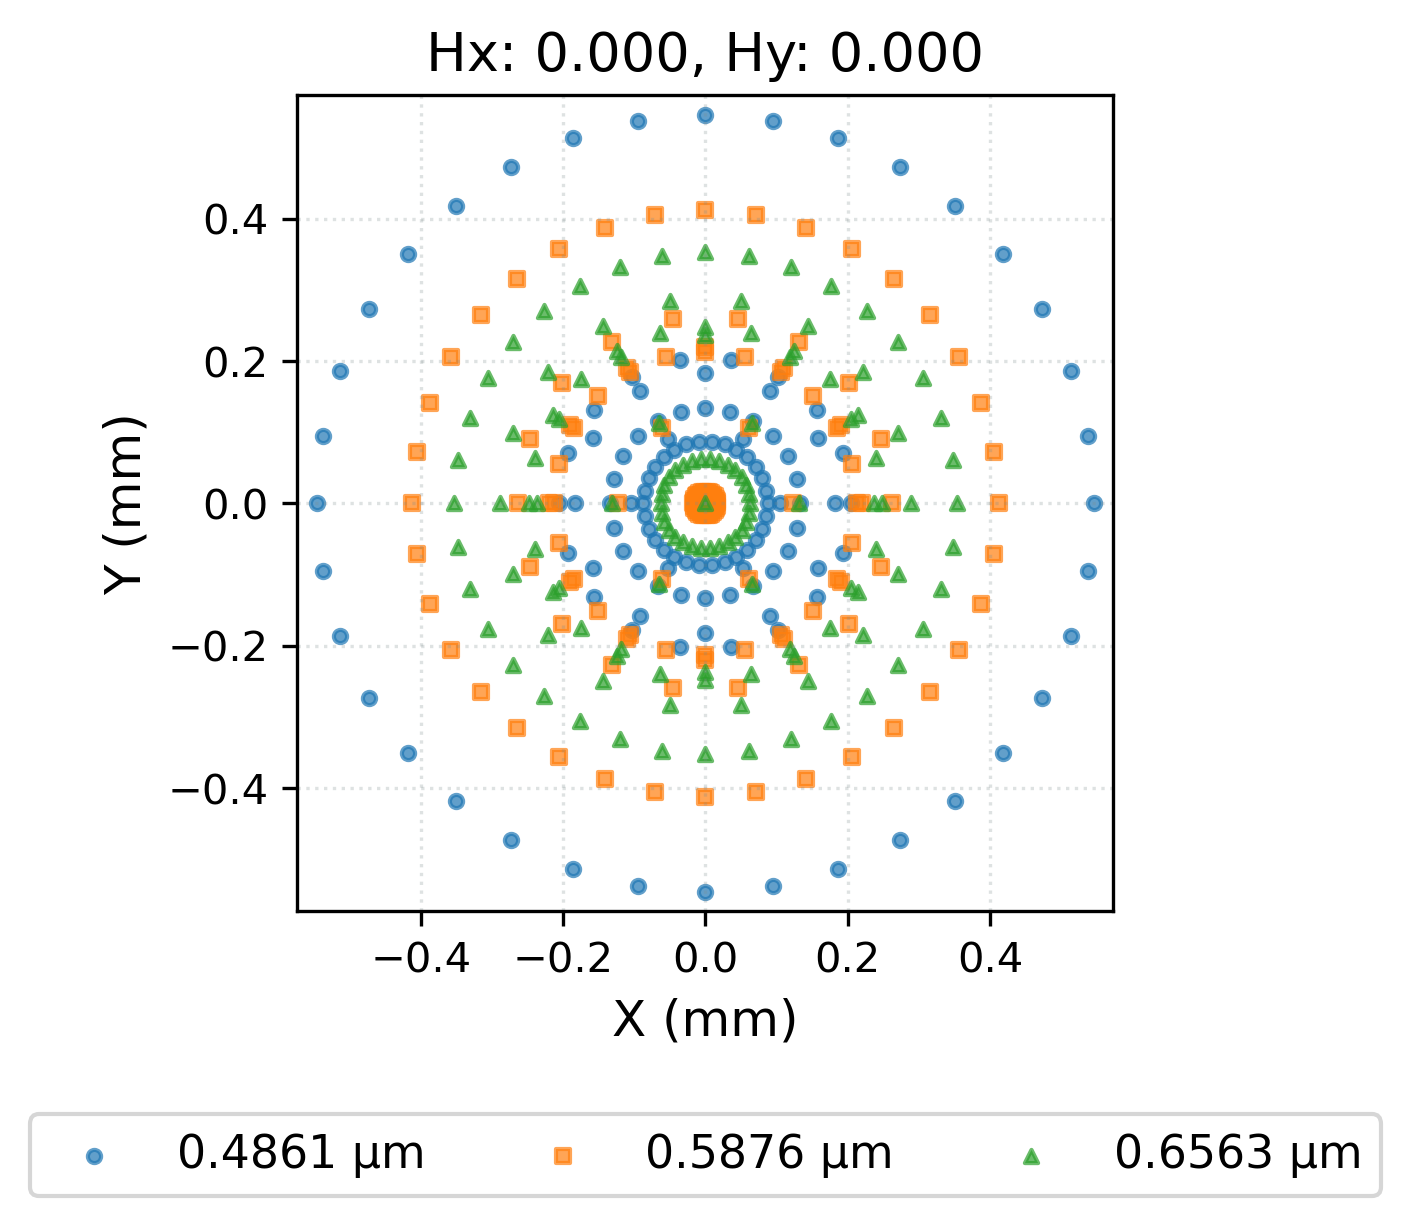

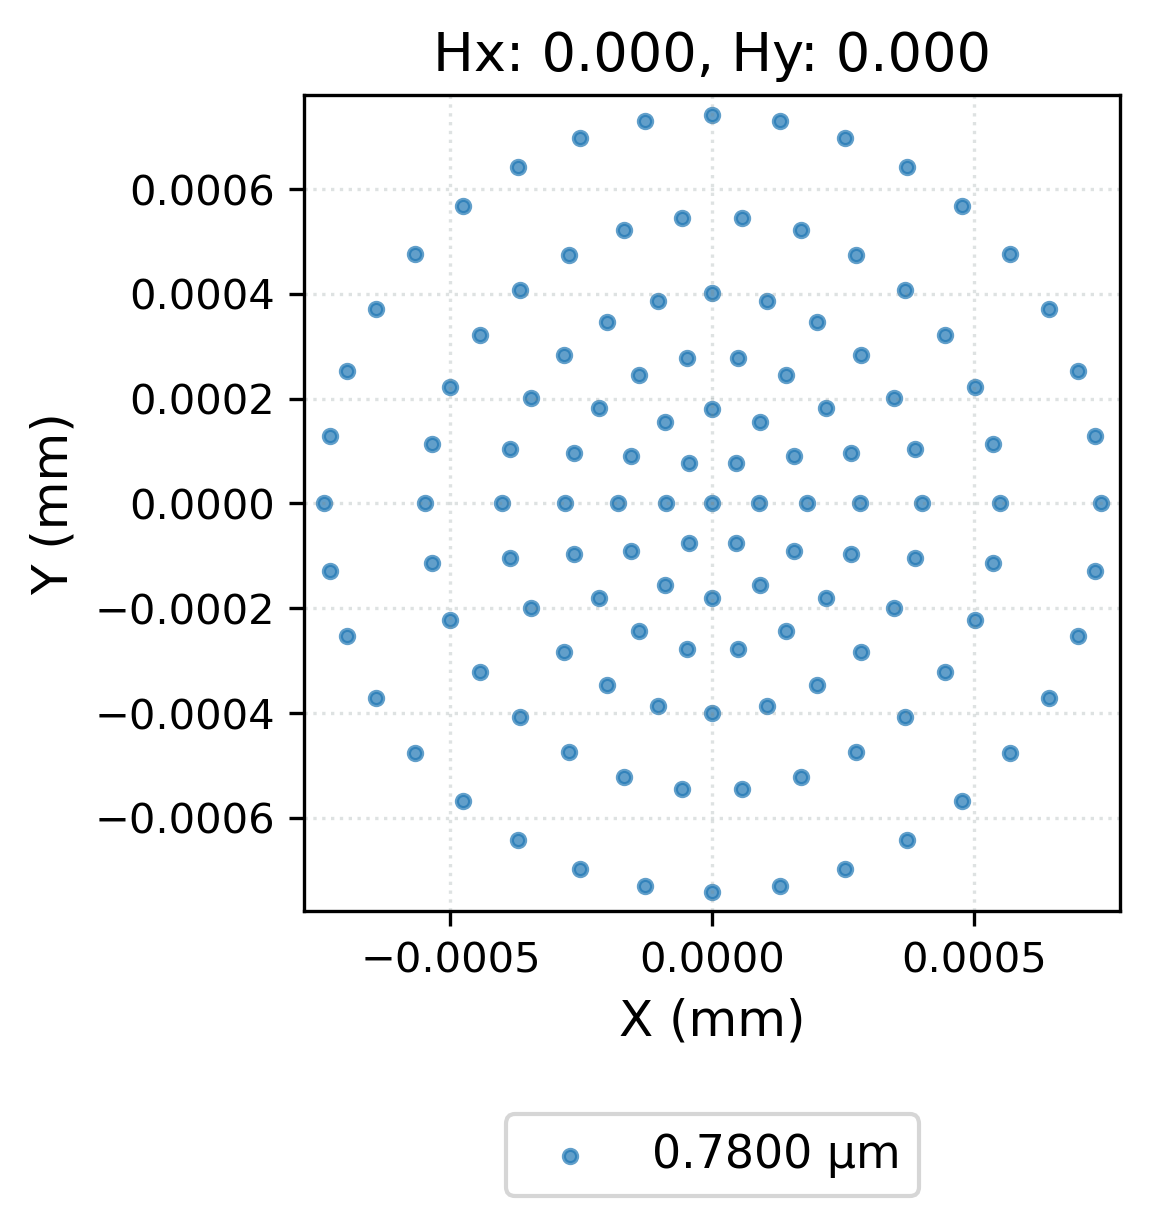

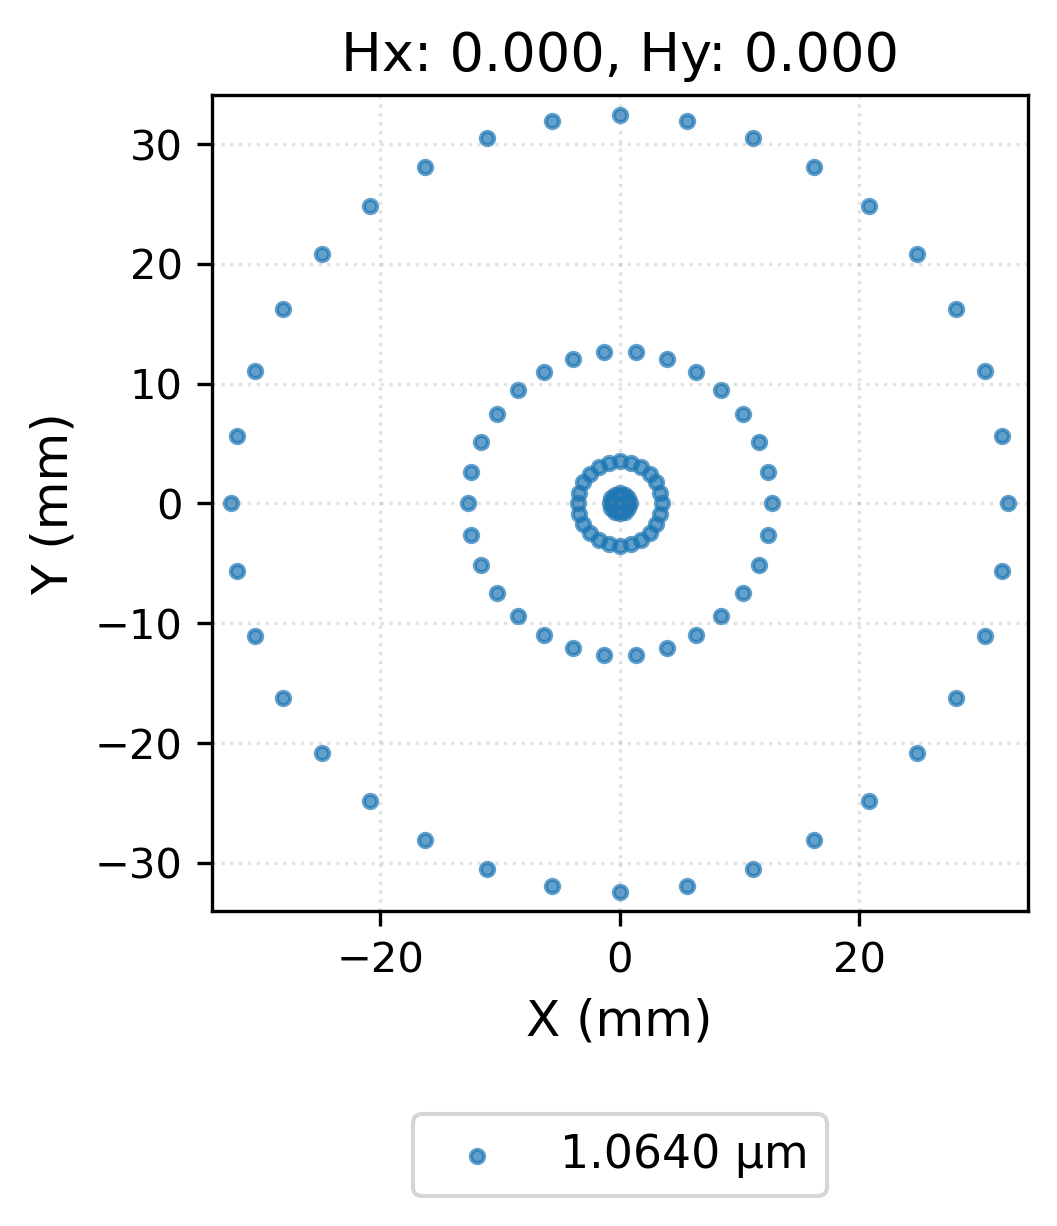

In [23]:
# === 1. URLs der Thorlabs .zmx Dateien ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 2. Linsen laden ===
print("Lade optische Modelle...")
lens_sphaere = load_zemax_file(url_sphaere)
lens_asphaere = load_zemax_file(url_asphaere)
lens_kolli = load_zemax_file(url_kolli)

# === 3. Nominale Spot-Diagramme generieren und anzeigen ===

# (a) Sphärische Linse
print("\n--- Spot Diagram: Spherical Lens (LA1422-C) ---")
spot_sphaere = analysis.SpotDiagram(lens_sphaere)
spot_sphaere.view()

# (b) Asphärische Linse
print("\n--- Spot Diagram: Aspheric Lens (AL5040H-B) ---")
spot_asphaere = analysis.SpotDiagram(lens_asphaere)
spot_asphaere.view()

# (c) Faser-Kollimator
print("\n--- Spot Diagram: Fiber Collimator (F810APC-1064) ---")
spot_kolli = analysis.SpotDiagram(lens_kolli)
spot_kolli.view()

Generiere Spot-Diagramme...
✅ Gespeichert: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Spot_Diagram_Spherical.pdf
✅ Gespeichert: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Spot_Diagram_Aspheric.pdf
✅ Gespeichert: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Spot_Diagram_Collimator.pdf


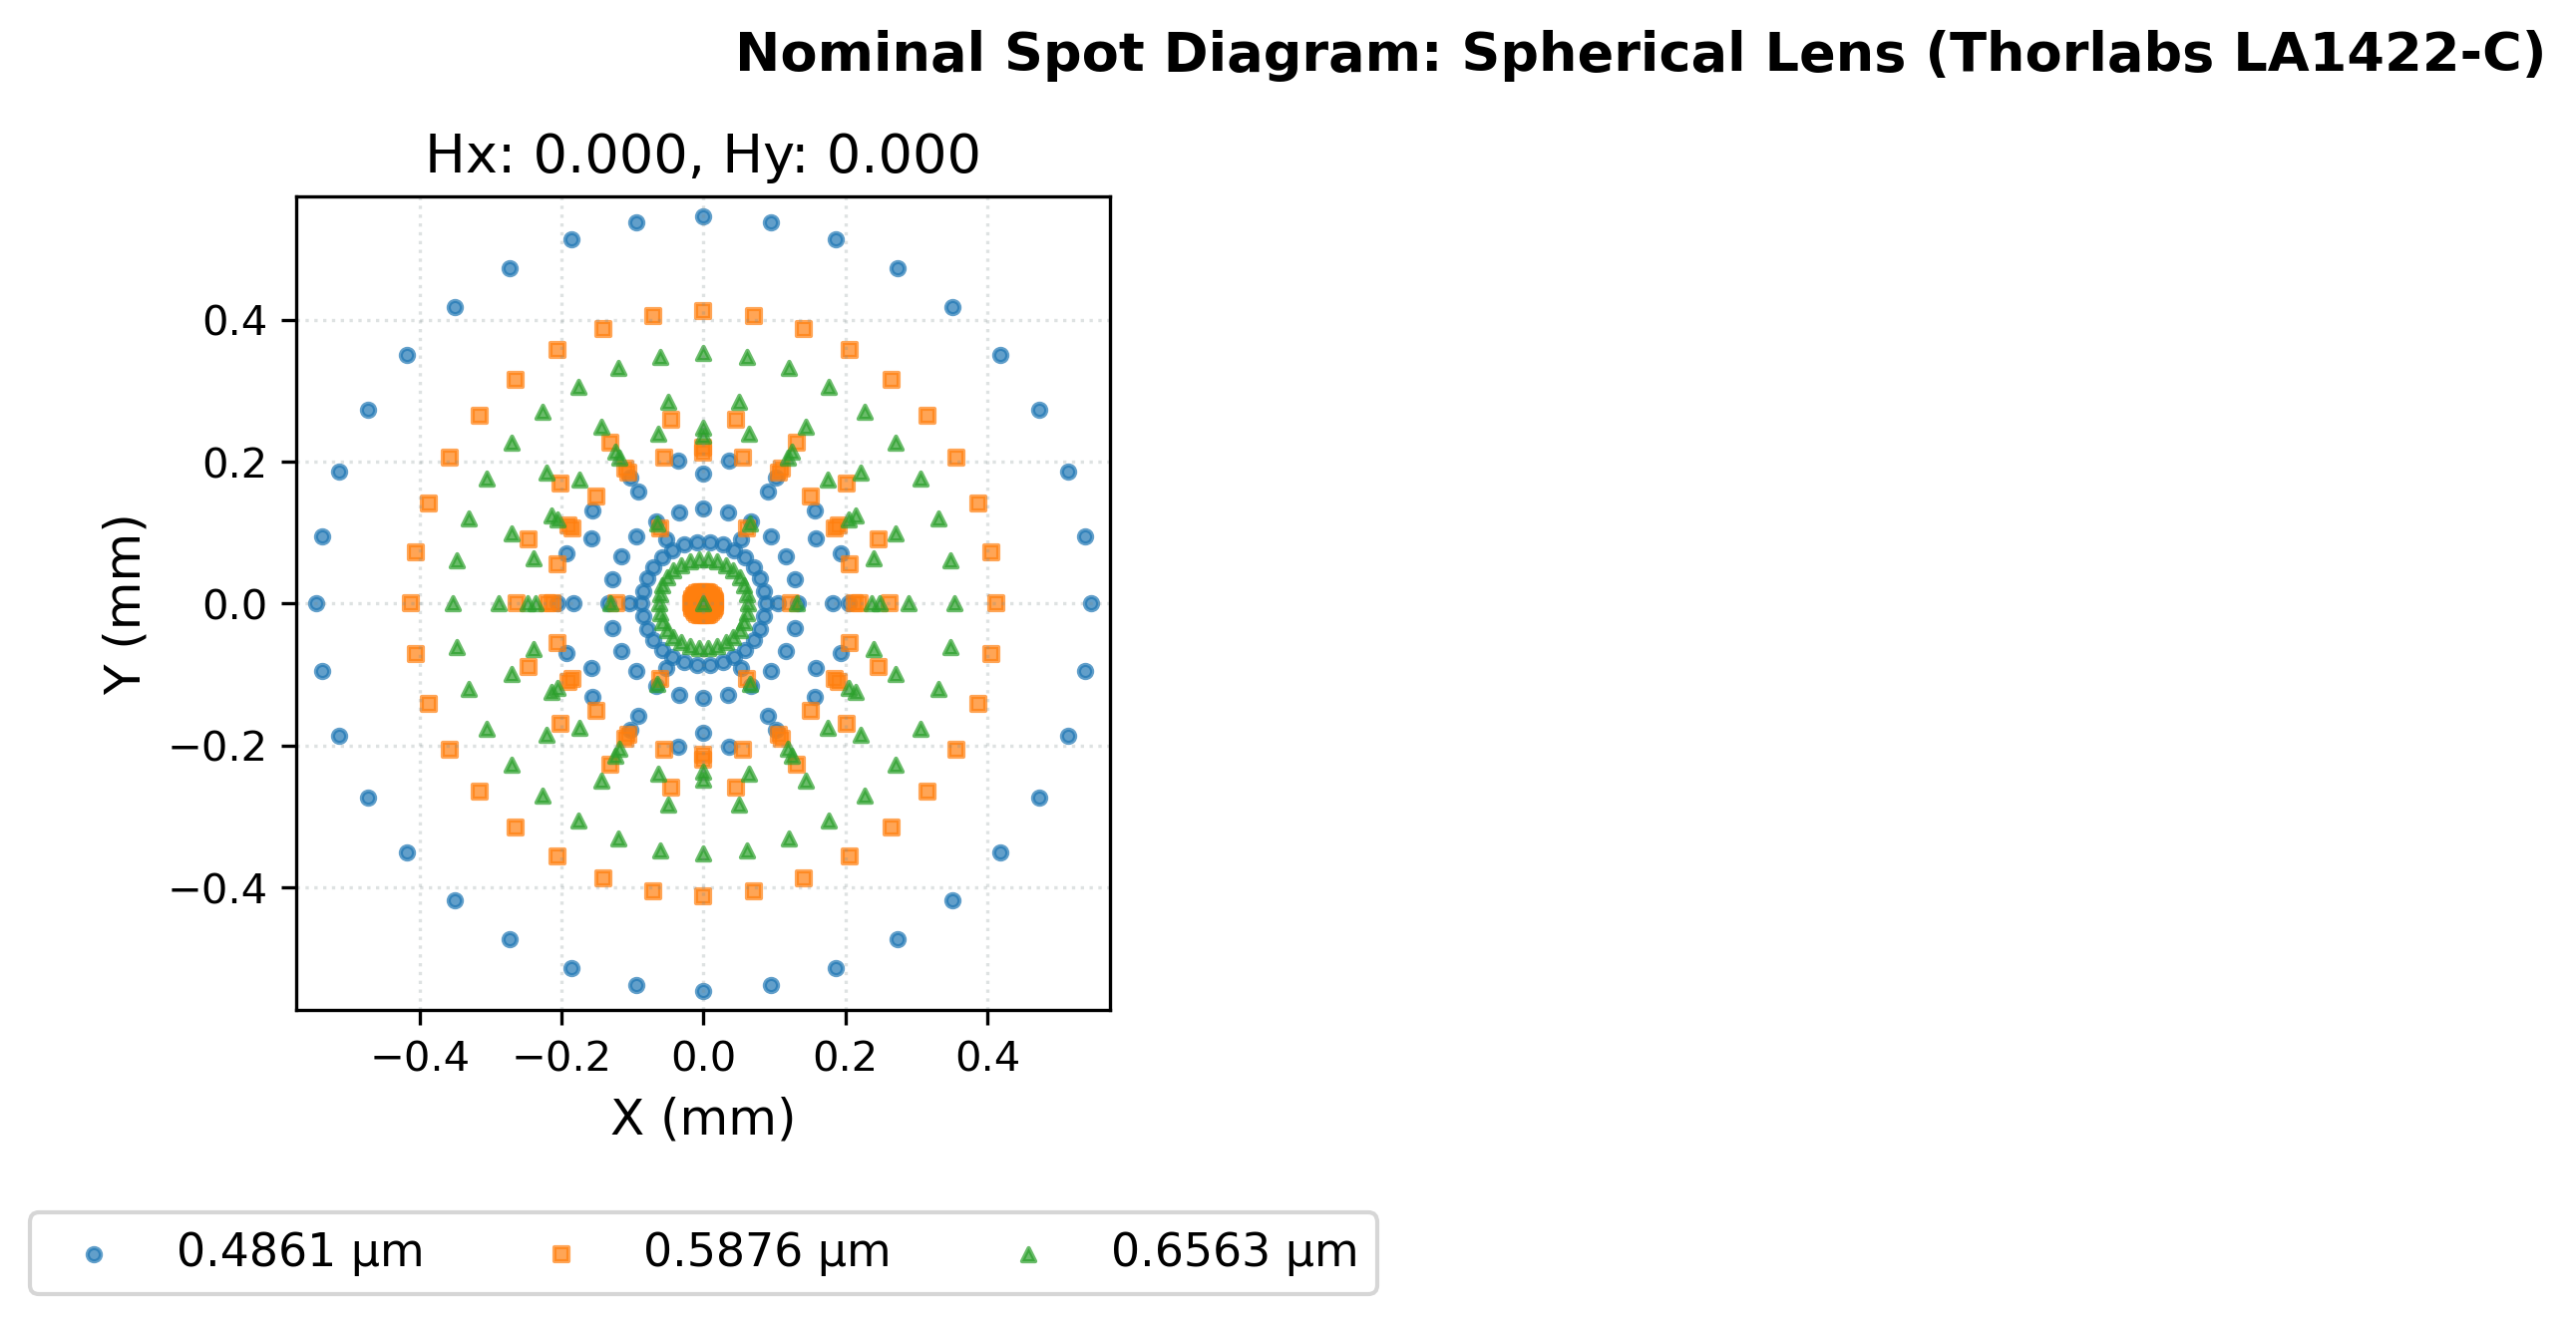

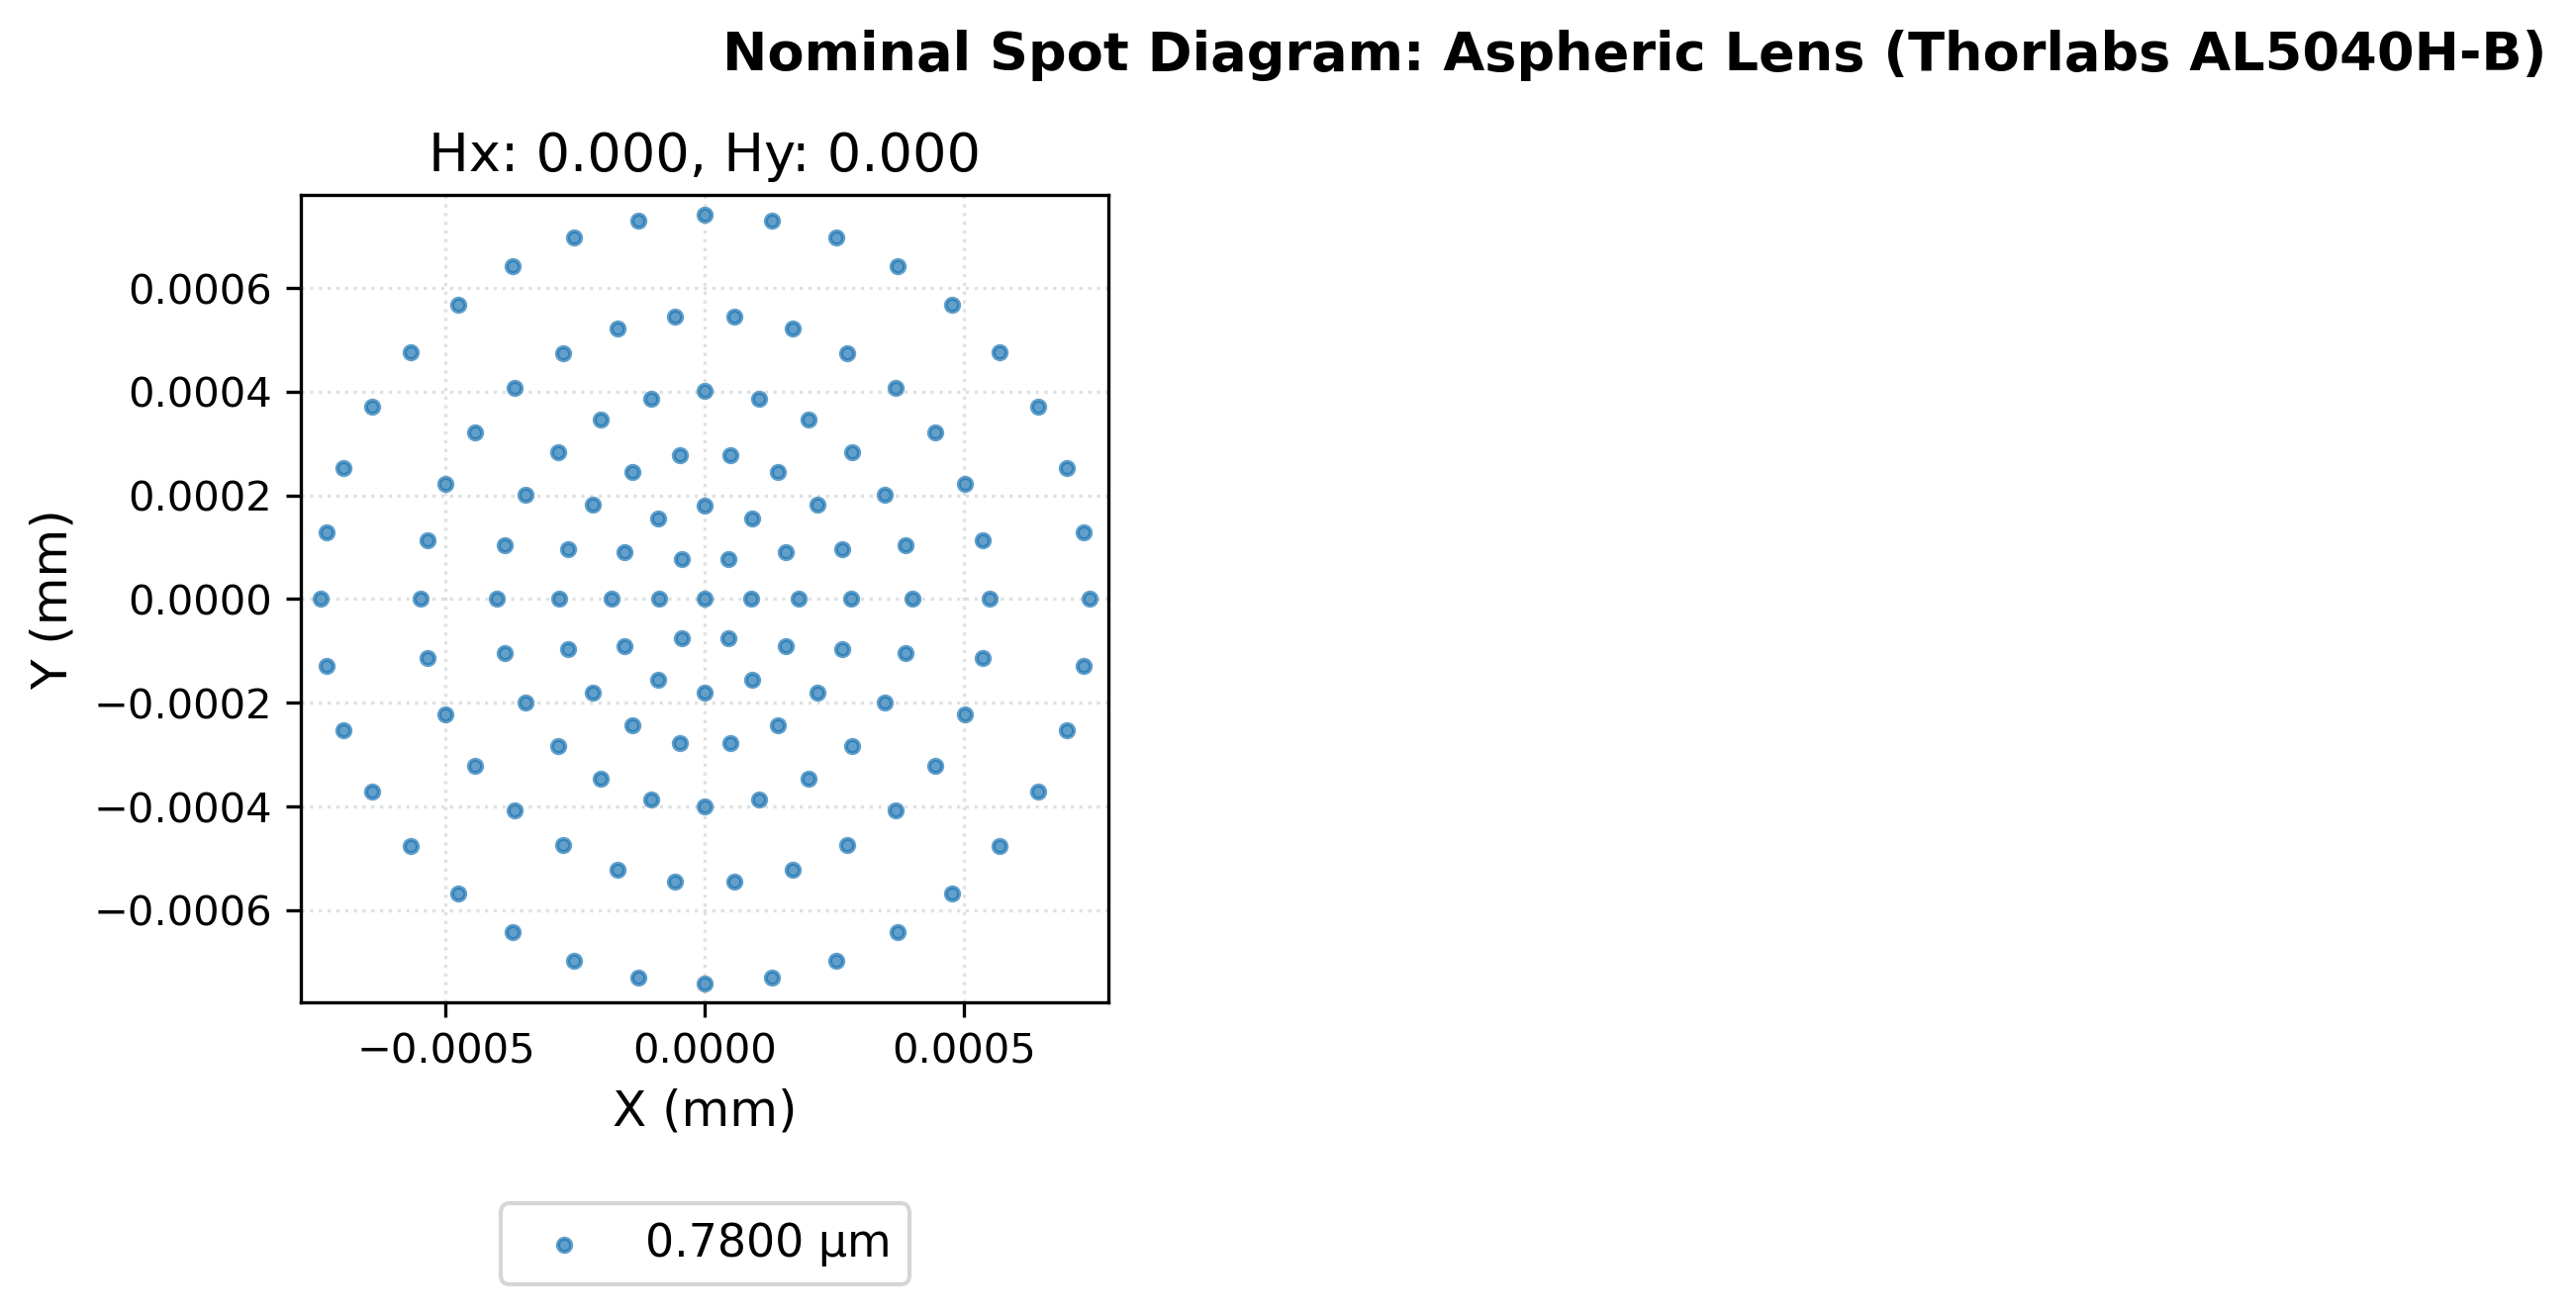

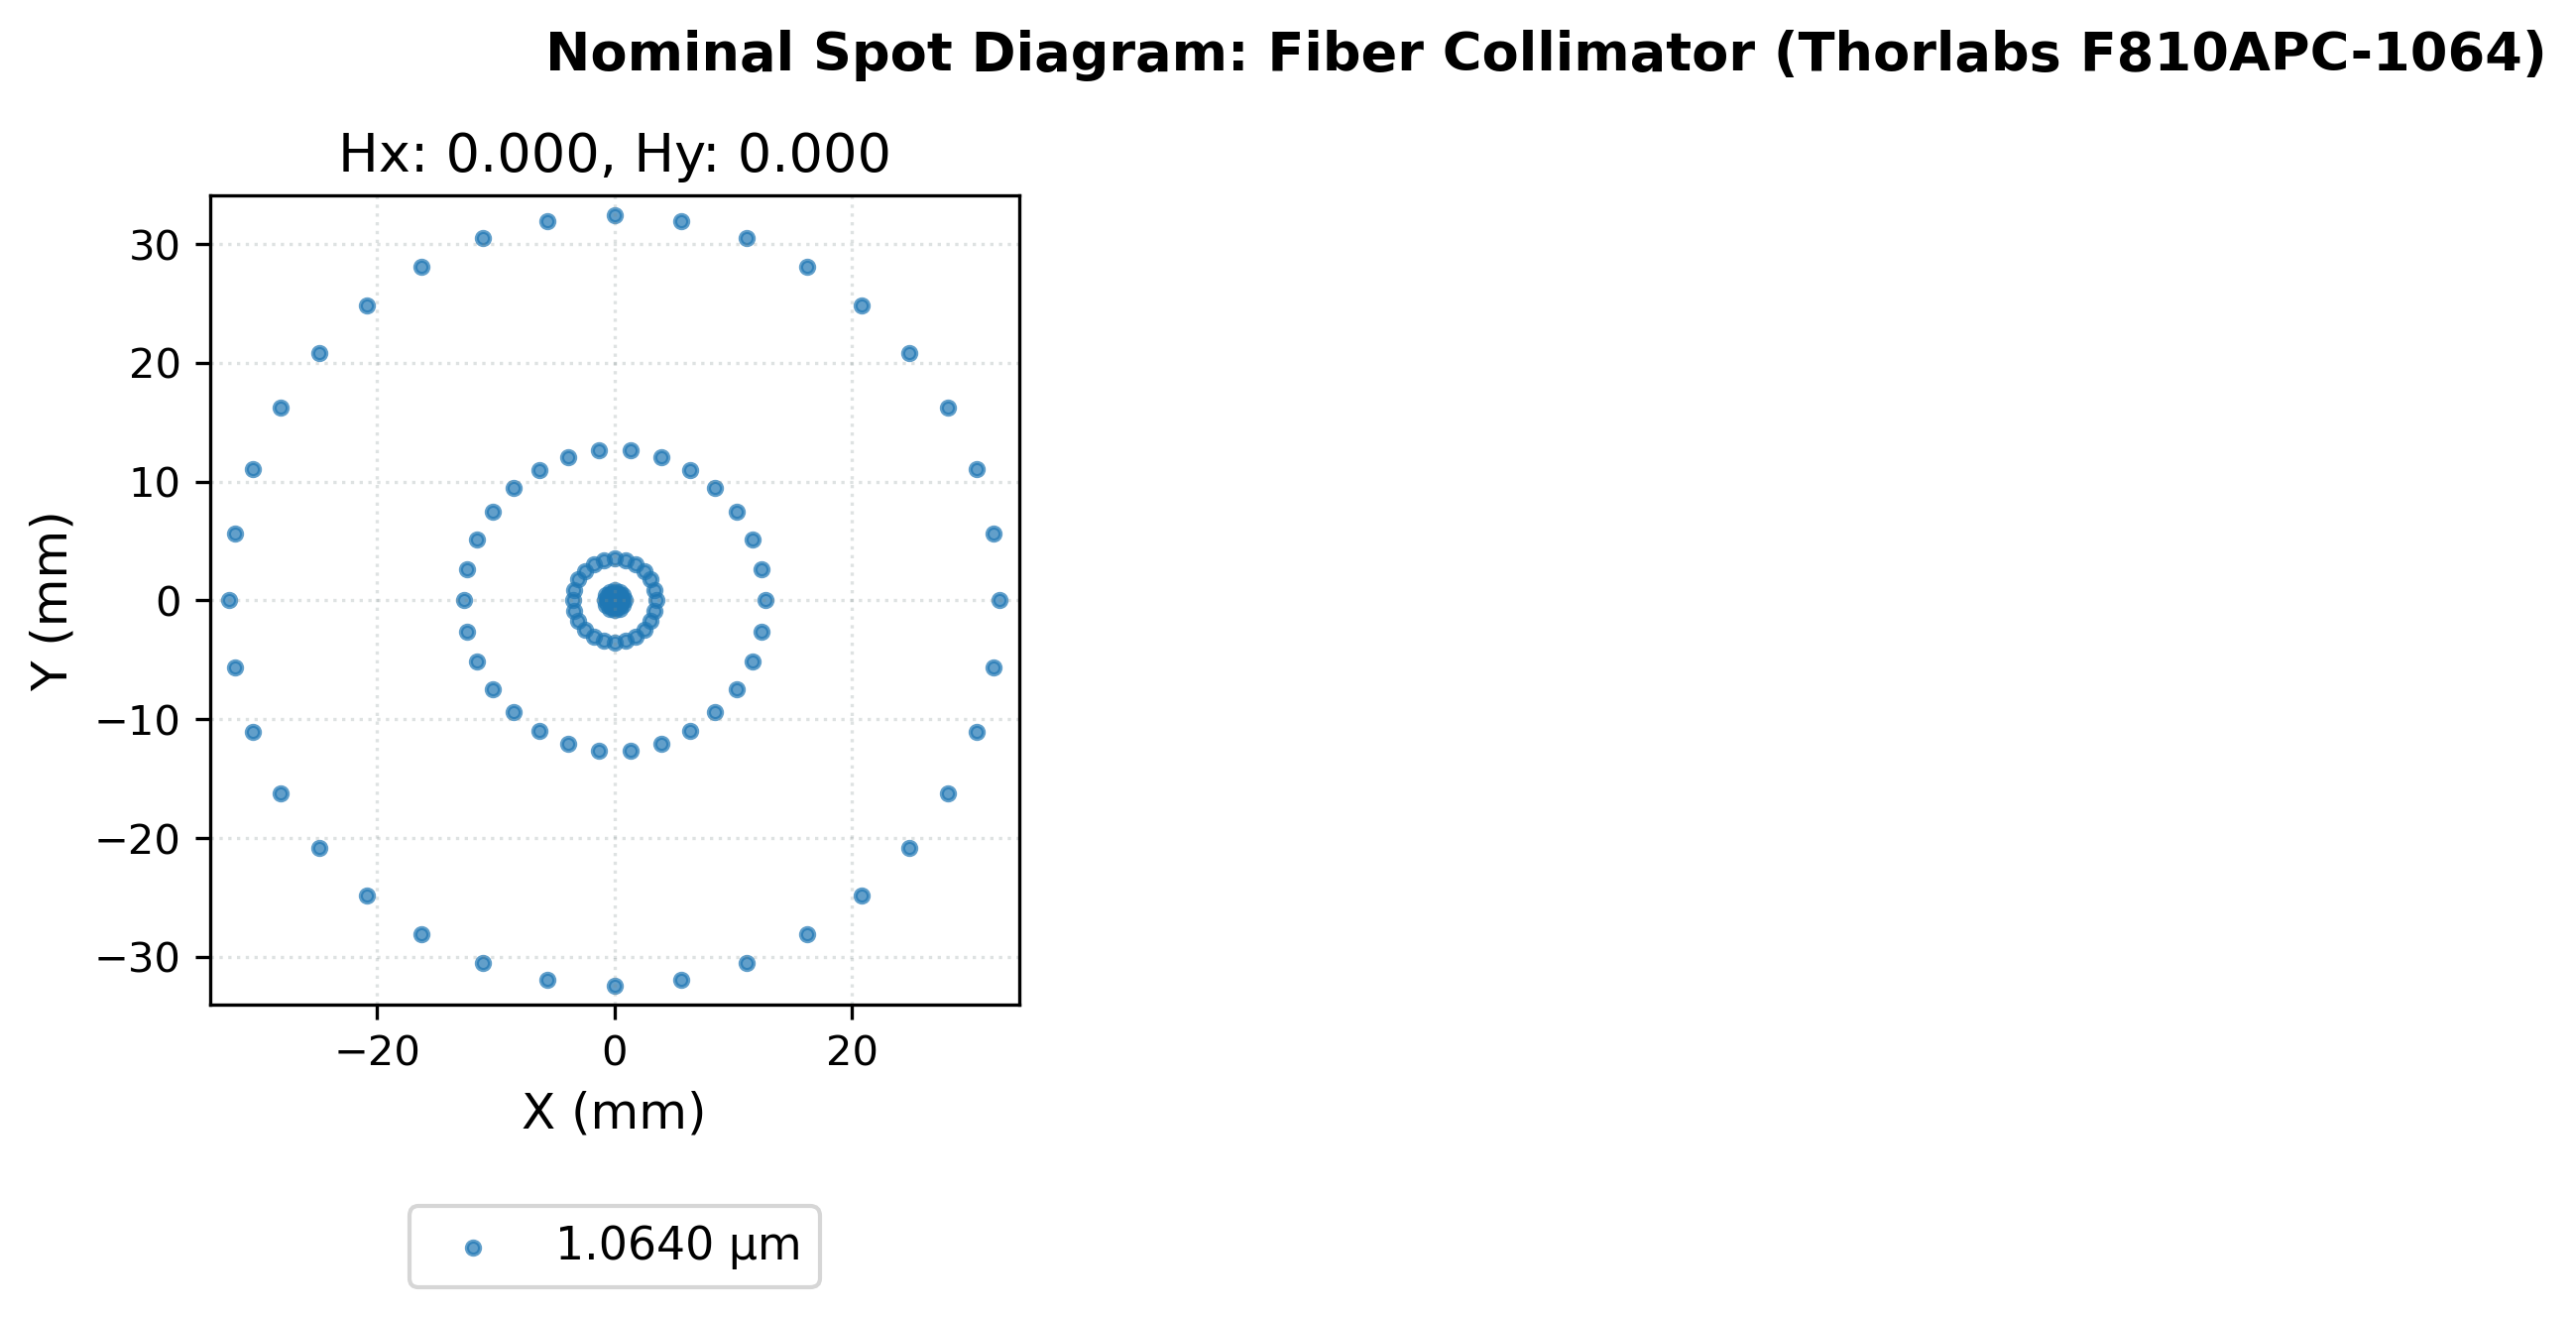

In [24]:


# === 1. Zielordner für deine Thesis definieren ===
output_dir = r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === 2. Linsen laden ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

lens_sphaere = load_zemax_file(url_sphaere)
lens_asphaere = load_zemax_file(url_asphaere)
lens_kolli = load_zemax_file(url_kolli)

# === 3. Python-Trick: Titel in Optiland erzwingen ===
# Wir sichern die originale plt.show Funktion
original_show = plt.show

def zeige_und_speichere_spot(lens, title, filename):
    # Wir bauen ein "gehacktes" plt.show, das unseren Titel setzt, bevor das Bild rendert
    def custom_show(*args, **kwargs):
        fig = plt.gcf()
        
        # Titel oben zentriert einfügen
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
        
        # Layout anpassen und als PDF exportieren
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches="tight")
        print(f"✅ Gespeichert: {filepath}")
        
        # Das echte plt.show aufrufen, damit das Bild im Notebook erscheint
        original_show(*args, **kwargs)
        
    # Wir jubeln Optiland temporär unsere eigene Funktion unter
    plt.show = custom_show
    
    # Optiland generiert das Spot-Diagramm ganz normal
    spot = analysis.SpotDiagram(lens)
    spot.view()
    
    # Danach stellen wir das Original wieder her
    plt.show = original_show

# === 4. Diagramme generieren ===
print("Generiere Spot-Diagramme...")

zeige_und_speichere_spot(
    lens_sphaere, 
    "Nominal Spot Diagram: Spherical Lens (Thorlabs LA1422-C)", 
    "Spot_Diagram_Spherical.pdf"
)

zeige_und_speichere_spot(
    lens_asphaere, 
    "Nominal Spot Diagram: Aspheric Lens (Thorlabs AL5040H-B)", 
    "Spot_Diagram_Aspheric.pdf"
)

zeige_und_speichere_spot(
    lens_kolli, 
    "Nominal Spot Diagram: Fiber Collimator (Thorlabs F810APC-1064)", 
    "Spot_Diagram_Collimator.pdf"
)

Loading optical models...
Extracting raw data for spot diagrams...
✅ Side-by-Side plot saved at: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Spot_Diagram_SideBySide_Classified.pdf


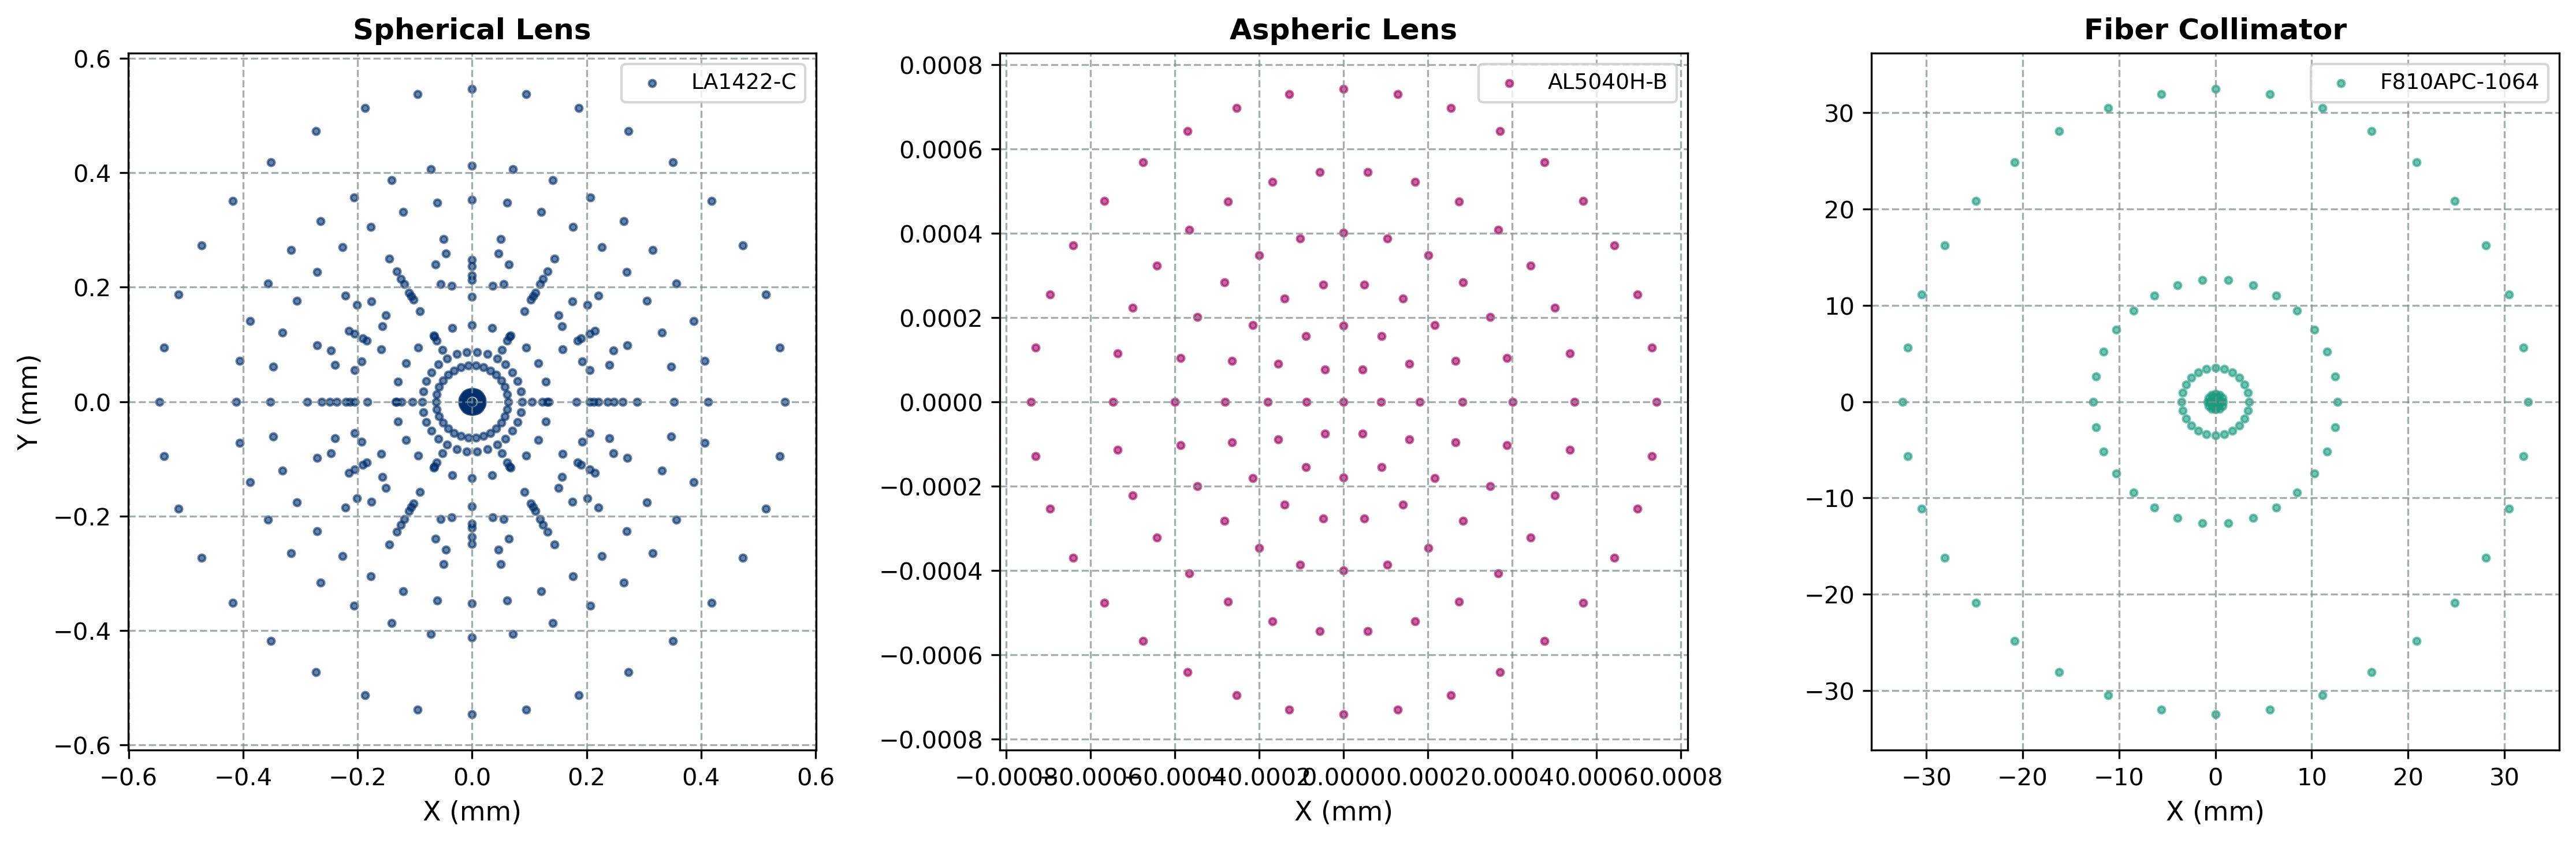

In [27]:
# === 1. Load Lenses ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

print("Loading optical models...")
lens_sphaere = load_zemax_file(url_sphaere)
lens_asphaere = load_zemax_file(url_asphaere)
lens_kolli = load_zemax_file(url_kolli)

# === 2. Function to Extract Spot Data ===
def extract_spot_data(lens):
    # Temporarily block matplotlib from popping open windows
    original_show = plt.show
    plt.show = lambda: None
    
    # Let Optiland calculate and draw the spot in the background
    spot = analysis.SpotDiagram(lens)
    spot.view()
    
    # Grab the hidden axis and extract X/Y scatter data
    ax = plt.gca()
    x_data, y_data = [], []
    
    for collection in ax.collections:
        offsets = collection.get_offsets()
        if len(offsets) > 0:
            x_data.extend(offsets[:, 0])
            y_data.extend(offsets[:, 1])
            
    # Close the hidden window cleanly and restore plt.show
    plt.close(plt.gcf())
    plt.show = original_show
    
    return x_data, y_data

# === 3. Extract Data ===
print("Extracting raw data for spot diagrams...")
x_sph, y_sph = extract_spot_data(lens_sphaere)
x_asph, y_asph = extract_spot_data(lens_asphaere)
x_kolli, y_kolli = extract_spot_data(lens_kolli)

# === 4. Build the 1x3 Side-by-Side Plot ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Sphere
axes[0].scatter(x_sph, y_sph, color='#002F6C', s=8, alpha=0.6, label="LA1422-C")
axes[0].set_title("Spherical Lens", fontsize=12, fontweight="bold")
axes[0].set_xlabel("X (mm)", fontsize=11)
axes[0].set_ylabel("Y (mm)", fontsize=11)

# Plot 2: Asphere
axes[1].scatter(x_asph, y_asph, color='#9E005D', s=8, alpha=0.6, label="AL5040H-B")
axes[1].set_title("Aspheric Lens", fontsize=12, fontweight="bold")
axes[1].set_xlabel("X (mm)", fontsize=11)

# Plot 3: Collimator
axes[2].scatter(x_kolli, y_kolli, color='#179C7D', s=8, alpha=0.6, label="F810APC-1064")
axes[2].set_title("Fiber Collimator", fontsize=12, fontweight="bold")
axes[2].set_xlabel("X (mm)", fontsize=11)

# Format Grid, Legend, and Proportions for all 3 plots
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.7)
    # Ensure circles remain perfectly round and undistorted
    ax.set_aspect('equal', adjustable='datalim')
    # Add a clean legend to the top right of each subplot
    ax.legend(loc="upper right", fontsize=9)

# Optimize spacing
plt.tight_layout()

# === 5. Save and Show ===
output_dir = r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

filepath = os.path.join(output_dir, "Spot_Diagram_SideBySide_Classified.pdf")
plt.savefig(filepath, bbox_inches="tight")
print(f"✅ Side-by-Side plot saved at: {filepath}")

# Display the final polished plot
plt.show()